# 🌳 Week 5 - Lab 3: Decision Trees and Random Forests

## Session 23: Classification Models II - Building Powerful Ensemble Models

---

### 📚 Learning Objectives

By the end of this lab, you will be able to:

1. **Understand** how Decision Trees make predictions through recursive splitting
2. **Build and visualize** Decision Tree classifiers
3. **Understand** the concept of ensemble learning and Random Forests
4. **Implement** Random Forest classifiers and understand their advantages
5. **Extract and interpret** feature importance from tree-based models
6. **Tune hyperparameters** to optimize model performance
7. **Compare** Decision Trees vs Random Forests

---

### 🎯 Today's Focus: From Single Trees to Forest Power!

We'll explore how Decision Trees work (intuitive, interpretable) and then see how combining many trees into a Random Forest creates a more powerful and robust model.

**Key Concepts:**
- Decision Trees: "If-then" rules learned from data
- Random Forests: "Wisdom of the crowd" - many trees voting together
- Feature Importance: Which features matter most for predictions?

---

## Part 1: Setup and Data Loading

Let's import all necessary libraries and load our dataset.

In [1]:
# ============================================================
# CELL 1: Import Required Libraries
# ============================================================
# Run this cell first to import all necessary packages

# Core data manipulation libraries
import numpy as np                    # Numerical computing
import pandas as pd                   # Data manipulation and analysis

# Visualization libraries
import matplotlib.pyplot as plt       # Basic plotting
import seaborn as sns                 # Statistical visualization

# Scikit-learn: Machine Learning library
from sklearn.datasets import load_wine           # Wine dataset (multi-class)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Tree-based models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully!")
print("\n📦 Key packages we'll use:")
print("   • DecisionTreeClassifier - Single decision tree model")
print("   • RandomForestClassifier - Ensemble of decision trees")
print("   • plot_tree - Visualize decision tree structure")
print("   • GridSearchCV - Hyperparameter tuning")

✅ All libraries imported successfully!

📦 Key packages we'll use:
   • DecisionTreeClassifier - Single decision tree model
   • RandomForestClassifier - Ensemble of decision trees
   • plot_tree - Visualize decision tree structure
   • GridSearchCV - Hyperparameter tuning


In [2]:
# ============================================================
# CELL 2: Load the Wine Dataset
# ============================================================
# We'll use the Wine dataset - a classic multi-class classification problem
# Goal: Classify wines into 3 categories based on chemical properties

# Load the wine dataset from sklearn
wine = load_wine()

# Create a DataFrame for easier manipulation
# wine.data contains the features, wine.feature_names has column names
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target variable (wine class: 0, 1, or 2)
df['target'] = wine.target

# Map target numbers to meaningful names
target_names = {0: 'Class_0', 1: 'Class_1', 2: 'Class_2'}
df['wine_class'] = df['target'].map(target_names)

# Display dataset information
print("🍷 WINE DATASET LOADED")
print("=" * 50)
print(f"\n📊 Dataset Shape: {df.shape[0]} samples × {df.shape[1]} columns")
print(f"\n🎯 Target Classes: {wine.target_names}")
print(f"\n📋 Features ({len(wine.feature_names)}):")
for i, name in enumerate(wine.feature_names, 1):
    print(f"   {i:2d}. {name}")

print("\n" + "=" * 50)
print("\n🔍 First 5 rows of the dataset:")
df.head()

🍷 WINE DATASET LOADED

📊 Dataset Shape: 178 samples × 15 columns

🎯 Target Classes: ['class_0' 'class_1' 'class_2']

📋 Features (13):
    1. alcohol
    2. malic_acid
    3. ash
    4. alcalinity_of_ash
    5. magnesium
    6. total_phenols
    7. flavanoids
    8. nonflavanoid_phenols
    9. proanthocyanins
   10. color_intensity
   11. hue
   12. od280/od315_of_diluted_wines
   13. proline


🔍 First 5 rows of the dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class_0


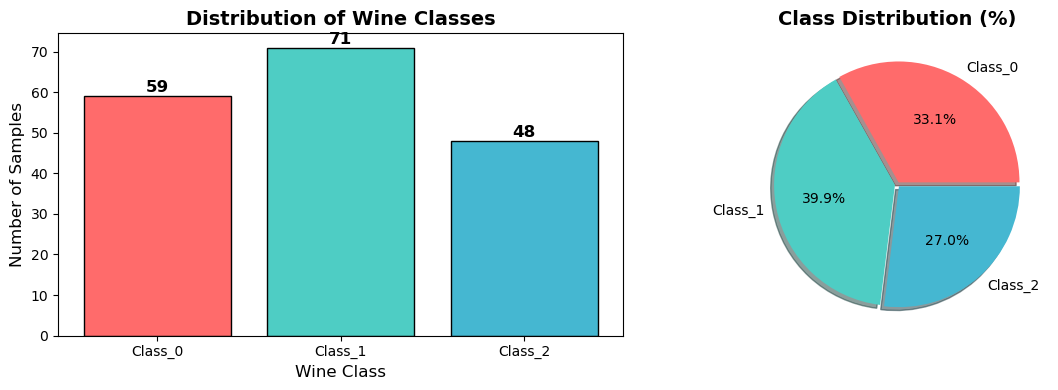


📊 Class Distribution Summary:
wine_class
Class_0    59
Class_1    71
Class_2    48

✅ Dataset is relatively balanced - good for classification!


In [3]:
# ============================================================
# CELL 3: Explore the Target Distribution
# ============================================================
# Let's see how many samples we have in each wine class

# Count samples per class
class_counts = df['wine_class'].value_counts().sort_index()

# Create a bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Wine Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Distribution of Wine Classes', fontsize=14, fontweight='bold')

# Add count labels on bars
for i, (idx, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, explode=[0.02, 0.02, 0.02], shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Class Distribution Summary:")
print(class_counts.to_string())
print(f"\n✅ Dataset is relatively balanced - good for classification!")

In [4]:
# ============================================================
# CELL 4: Prepare Data for Modeling
# ============================================================
# Split our data into features (X) and target (y)
# Then split into training and testing sets

# Separate features and target
X = df[wine.feature_names]  # All feature columns
y = df['target']            # Target column (0, 1, or 2)

# Split into training (80%) and testing (20%) sets
# stratify=y ensures each class is proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class proportions
)

print("📊 DATA SPLIT COMPLETE")
print("=" * 50)
print(f"\n🔹 Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"🔹 Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n🔹 Number of features: {X_train.shape[1]}")

print("\n📈 Class distribution in splits:")
print(f"   Training: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   Testing:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

📊 DATA SPLIT COMPLETE

🔹 Training set: 142 samples (80%)
🔹 Testing set:  36 samples (20%)

🔹 Number of features: 13

📈 Class distribution in splits:
   Training: {np.int64(0): np.int64(47), np.int64(1): np.int64(57), np.int64(2): np.int64(38)}
   Testing:  {np.int64(0): np.int64(12), np.int64(1): np.int64(14), np.int64(2): np.int64(10)}


---

## Part 2: Understanding Decision Trees

### How Decision Trees Work:

Decision Trees learn **if-then rules** from data by recursively splitting the dataset:

1. **Start at the root** with all training data
2. **Find the best feature and threshold** to split the data (maximize information gain)
3. **Create child nodes** for each split
4. **Repeat** until stopping criteria is met (max depth, min samples, etc.)
5. **Assign class labels** to leaf nodes based on majority class

**Key Concepts:**
- **Gini Impurity**: Measures how "mixed" the classes are at a node (0 = pure, 0.5 = maximum impurity for binary)
- **Information Gain**: Reduction in impurity after a split

In [5]:
# ============================================================
# CELL 5: Train a Basic Decision Tree
# ============================================================
# Let's create our first Decision Tree classifier

# Create a Decision Tree with default parameters
# Note: No max_depth means the tree will grow until all leaves are pure
dt_basic = DecisionTreeClassifier(
    random_state=42,      # For reproducibility
    criterion='gini'      # Use Gini impurity for splits (default)
)

# Train the model on our training data
dt_basic.fit(X_train, y_train)

# Make predictions on training and test sets
y_train_pred = dt_basic.predict(X_train)
y_test_pred = dt_basic.predict(X_test)

# Calculate accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("🌳 BASIC DECISION TREE TRAINED")
print("=" * 50)
print(f"\n📊 Tree Properties:")
print(f"   • Depth: {dt_basic.get_depth()}")
print(f"   • Number of leaves: {dt_basic.get_n_leaves()}")
print(f"   • Number of features used: {dt_basic.n_features_in_}")

print(f"\n🎯 Accuracy Results:")
print(f"   • Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   • Testing Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")

# Check for overfitting
if train_acc == 1.0 and test_acc < 0.95:
    print("\n⚠️  Warning: 100% training accuracy with lower test accuracy")
    print("   This suggests OVERFITTING - the tree memorized the training data!")

🌳 BASIC DECISION TREE TRAINED

📊 Tree Properties:
   • Depth: 4
   • Number of leaves: 8
   • Number of features used: 13

🎯 Accuracy Results:
   • Training Accuracy: 1.0000 (100.00%)
   • Testing Accuracy:  0.9444 (94.44%)

⚠️  Warning: 100% training accuracy with lower test accuracy
   This suggests OVERFITTING - the tree memorized the training data!


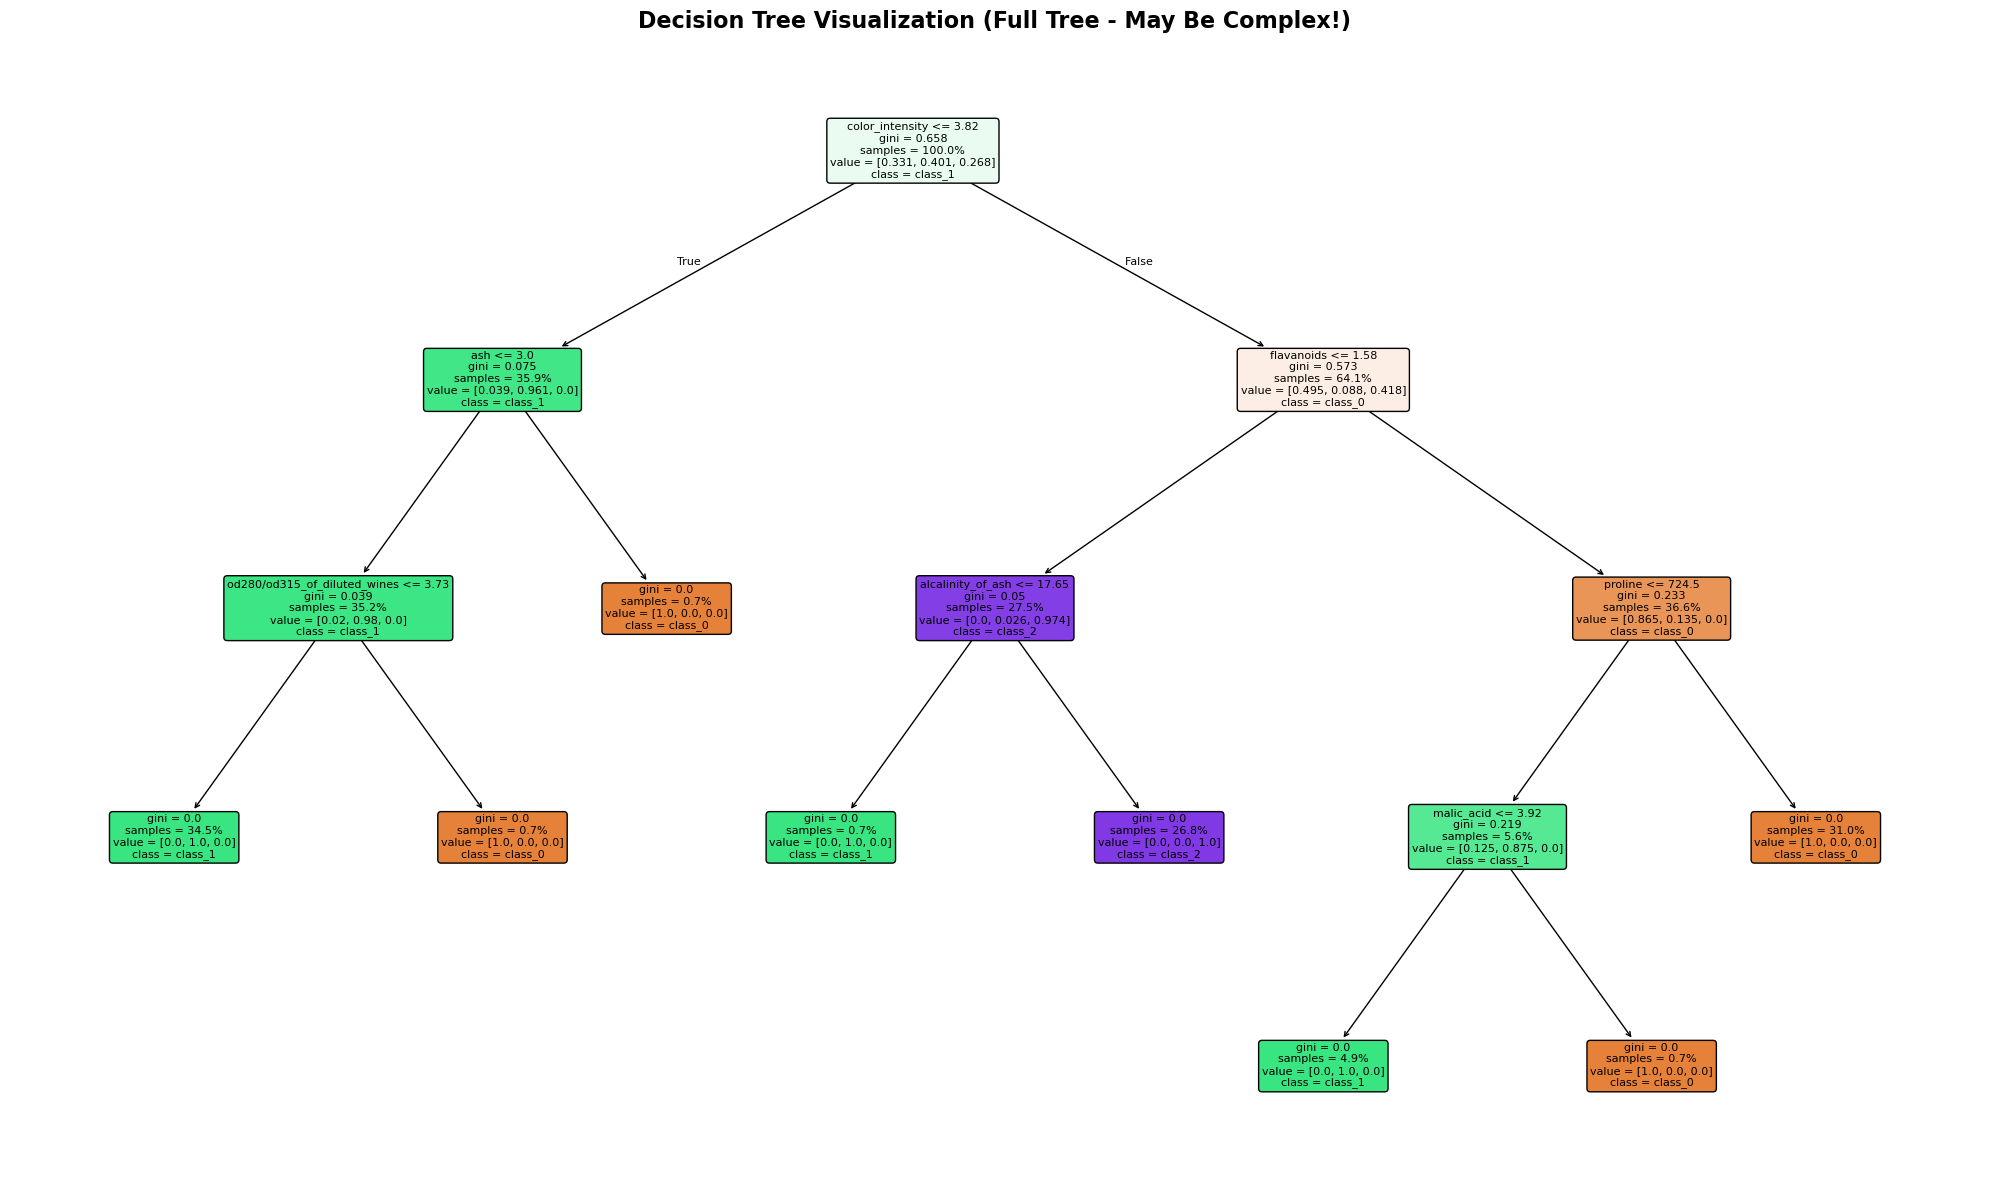


📖 How to Read the Tree:
   • Each box shows: feature ≤ threshold
   • 'gini': Impurity measure (0 = pure node)
   • 'samples': Percentage of training samples at this node
   • 'value': Distribution of classes [Class_0, Class_1, Class_2]
   • 'class': Predicted class if this were a leaf node
   • Colors: Darker = more pure (confident prediction)


In [6]:
# ============================================================
# CELL 6: Visualize the Decision Tree
# ============================================================
# One of the biggest advantages of Decision Trees: interpretability!
# We can visualize exactly how the model makes decisions

# Create a figure for the tree visualization
plt.figure(figsize=(20, 12))

# Plot the decision tree
plot_tree(
    dt_basic,                          # Our trained tree
    feature_names=wine.feature_names,  # Feature names for readability
    class_names=wine.target_names,     # Class names
    filled=True,                       # Color nodes by class
    rounded=True,                      # Rounded corners
    fontsize=8,                        # Font size
    proportion=True                    # Show proportions instead of counts
)

plt.title('Decision Tree Visualization (Full Tree - May Be Complex!)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📖 How to Read the Tree:")
print("   • Each box shows: feature ≤ threshold")
print("   • 'gini': Impurity measure (0 = pure node)")
print("   • 'samples': Percentage of training samples at this node")
print("   • 'value': Distribution of classes [Class_0, Class_1, Class_2]")
print("   • 'class': Predicted class if this were a leaf node")
print("   • Colors: Darker = more pure (confident prediction)")

🌳 SIMPLE DECISION TREE (max_depth=3)

📊 Tree Properties:
   • Depth: 3
   • Number of leaves: 7

🎯 Accuracy Comparison:
                    Full Tree    Simple Tree
   Training:        100.00%        99.30%
   Testing:          94.44%        94.44%


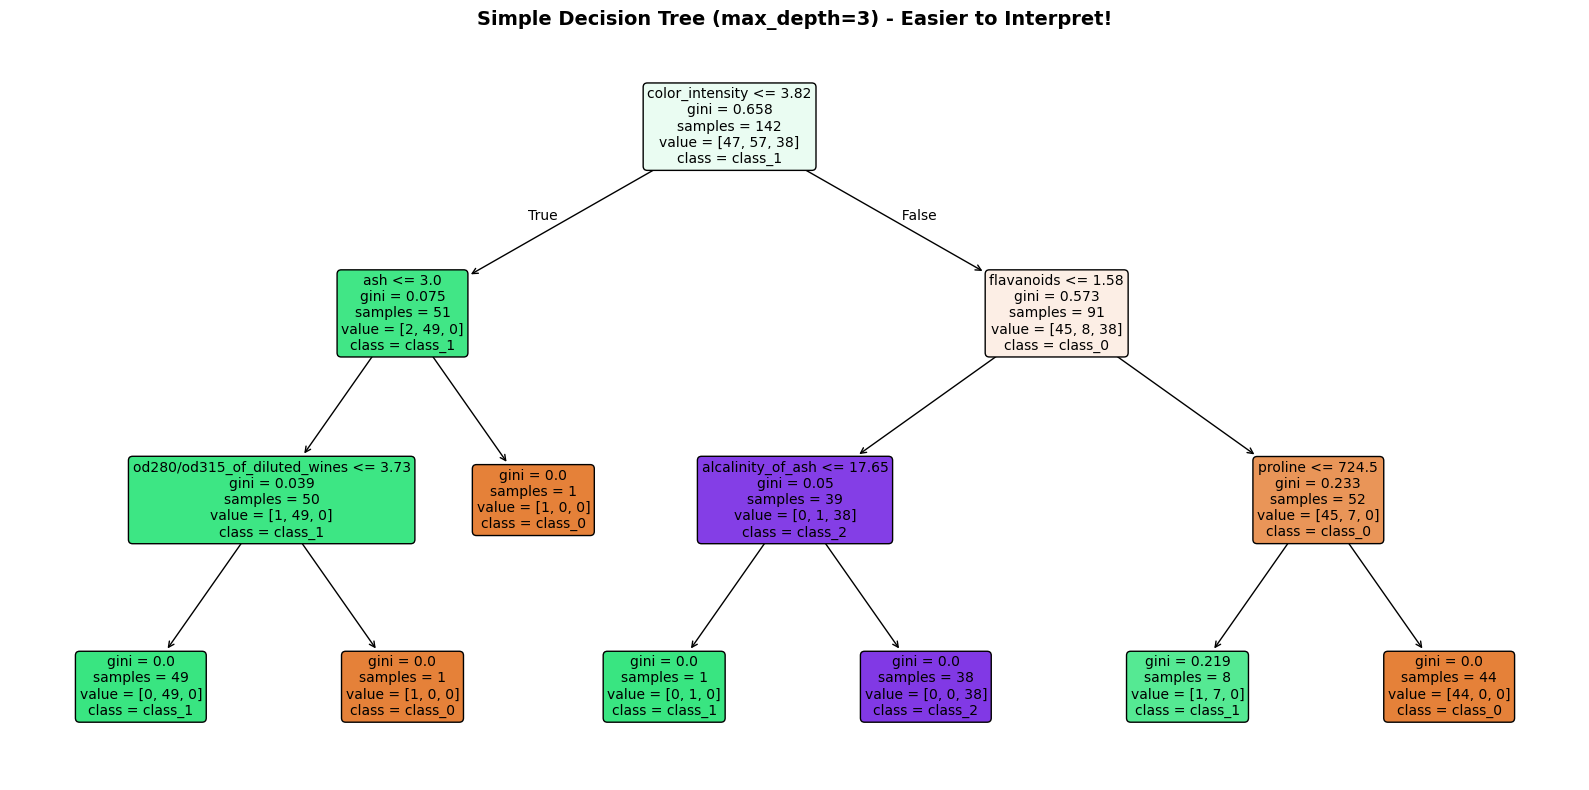

In [7]:
# ============================================================
# CELL 7: Create a Simpler Tree (Limit Depth)
# ============================================================
# Deep trees tend to overfit. Let's create a shallower tree
# that's easier to interpret and may generalize better

# Create a Decision Tree with limited depth
dt_simple = DecisionTreeClassifier(
    max_depth=3,          # Limit tree to 3 levels
    random_state=42,
    criterion='gini'
)

# Train the model
dt_simple.fit(X_train, y_train)

# Make predictions
y_train_pred_simple = dt_simple.predict(X_train)
y_test_pred_simple = dt_simple.predict(X_test)

# Calculate accuracy
train_acc_simple = accuracy_score(y_train, y_train_pred_simple)
test_acc_simple = accuracy_score(y_test, y_test_pred_simple)

print("🌳 SIMPLE DECISION TREE (max_depth=3)")
print("=" * 50)
print(f"\n📊 Tree Properties:")
print(f"   • Depth: {dt_simple.get_depth()}")
print(f"   • Number of leaves: {dt_simple.get_n_leaves()}")

print(f"\n🎯 Accuracy Comparison:")
print(f"                    Full Tree    Simple Tree")
print(f"   Training:        {train_acc*100:6.2f}%       {train_acc_simple*100:6.2f}%")
print(f"   Testing:         {test_acc*100:6.2f}%       {test_acc_simple*100:6.2f}%")

# Visualize the simpler tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt_simple,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Simple Decision Tree (max_depth=3) - Easier to Interpret!', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

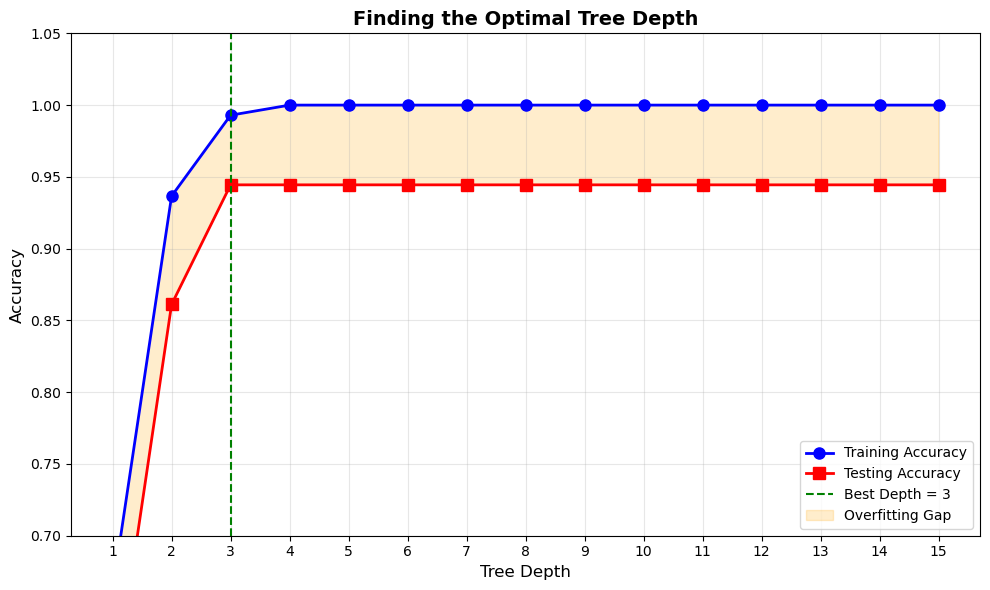


🎯 Optimal Tree Depth: 3
   Best Test Accuracy: 94.44%

💡 Observation: Notice how training accuracy keeps increasing with depth,
   but test accuracy plateaus or decreases - this is OVERFITTING!


In [8]:
# ============================================================
# CELL 8: Find Optimal Tree Depth
# ============================================================
# Let's systematically test different tree depths to find the best one

# Test depths from 1 to 15
depths = range(1, 16)
train_scores = []
test_scores = []

for depth in depths:
    # Create and train tree with this depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Record scores
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

# Find best depth based on test accuracy
best_depth = depths[np.argmax(test_scores)]
best_test_acc = max(test_scores)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(depths, test_scores, 'r-s', label='Testing Accuracy', linewidth=2, markersize=8)

# Mark the best depth
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')

# Shade overfitting region
plt.fill_between(depths, train_scores, test_scores, alpha=0.2, color='orange',
                 label='Overfitting Gap')

plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Finding the Optimal Tree Depth', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

print(f"\n🎯 Optimal Tree Depth: {best_depth}")
print(f"   Best Test Accuracy: {best_test_acc*100:.2f}%")
print("\n💡 Observation: Notice how training accuracy keeps increasing with depth,")
print("   but test accuracy plateaus or decreases - this is OVERFITTING!")

---

## Part 3: Random Forests - The Power of Ensemble Learning

### The Problem with Single Decision Trees:
- **High Variance**: Small changes in data can lead to very different trees
- **Overfitting**: Deep trees memorize training data

### The Solution: Random Forests! 🌲🌲🌲

A Random Forest is an **ensemble** of many Decision Trees that work together:

1. **Bootstrap Sampling**: Each tree trains on a random subset of data (with replacement)
2. **Feature Randomization**: Each split considers only a random subset of features
3. **Voting**: For classification, each tree votes and the majority wins

**Result**: More robust, less overfitting, better generalization!

In [9]:
# ============================================================
# CELL 9: Train a Random Forest
# ============================================================
# Let's create a Random Forest and see how it compares to a single tree

# Create a Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=100,     # Number of trees in the forest
    max_depth=None,       # Let trees grow fully
    min_samples_split=2,  # Minimum samples to split a node
    min_samples_leaf=1,   # Minimum samples in a leaf
    random_state=42,      # For reproducibility
    n_jobs=-1             # Use all CPU cores for parallel training
)

# Train the Random Forest
print("🌲 Training Random Forest with 100 trees...")
rf.fit(X_train, y_train)
print("✅ Training complete!")

# Make predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Calculate accuracy
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print("\n🌲 RANDOM FOREST RESULTS")
print("=" * 50)
print(f"\n📊 Forest Properties:")
print(f"   • Number of trees: {rf.n_estimators}")
print(f"   • Features per tree: {rf.n_features_in_}")

print(f"\n🎯 Accuracy:")
print(f"   • Training Accuracy: {train_acc_rf:.4f} ({train_acc_rf*100:.2f}%)")
print(f"   • Testing Accuracy:  {test_acc_rf:.4f} ({test_acc_rf*100:.2f}%)")

🌲 Training Random Forest with 100 trees...
✅ Training complete!

🌲 RANDOM FOREST RESULTS

📊 Forest Properties:
   • Number of trees: 100
   • Features per tree: 13

🎯 Accuracy:
   • Training Accuracy: 1.0000 (100.00%)
   • Testing Accuracy:  1.0000 (100.00%)


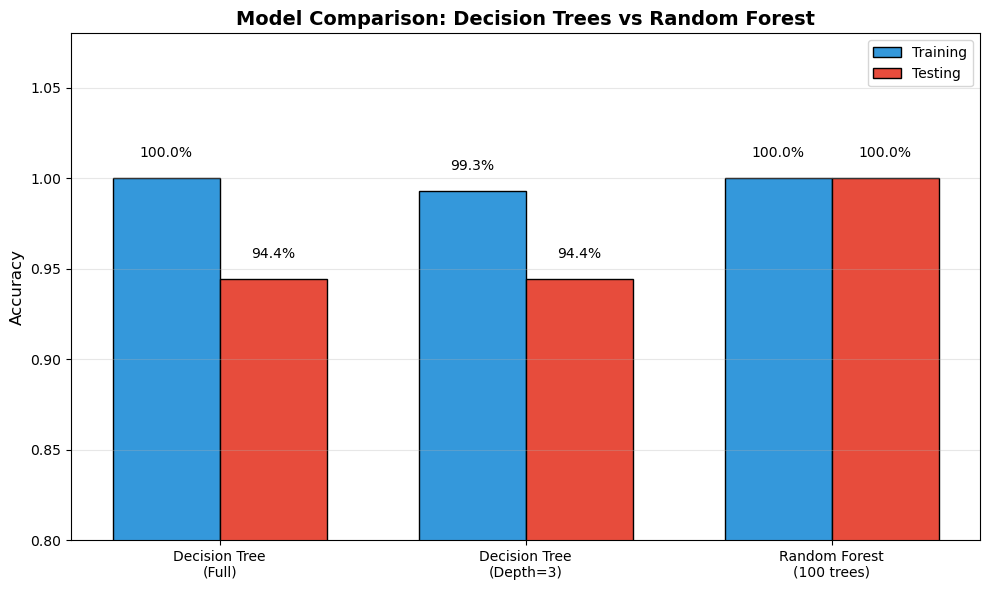


💡 Key Observations:
   • Full Decision Tree: Perfect training, may overfit
   • Simple Decision Tree: Less overfitting, but may underfit
   • Random Forest: Best of both worlds - high accuracy, good generalization!


In [10]:
# ============================================================
# CELL 10: Compare Single Tree vs Random Forest
# ============================================================
# Let's visually compare the performance of different models

# Collect all results
models = ['Decision Tree\n(Full)', 'Decision Tree\n(Depth=3)', 'Random Forest\n(100 trees)']
train_accs = [train_acc, train_acc_simple, train_acc_rf]
test_accs = [test_acc, test_acc_simple, test_acc_rf]

# Create comparison bar chart
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, train_accs, width, label='Training', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs, width, label='Testing', color='#e74c3c', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Comparison: Decision Trees vs Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.8, 1.08)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("   • Full Decision Tree: Perfect training, may overfit")
print("   • Simple Decision Tree: Less overfitting, but may underfit")
print("   • Random Forest: Best of both worlds - high accuracy, good generalization!")

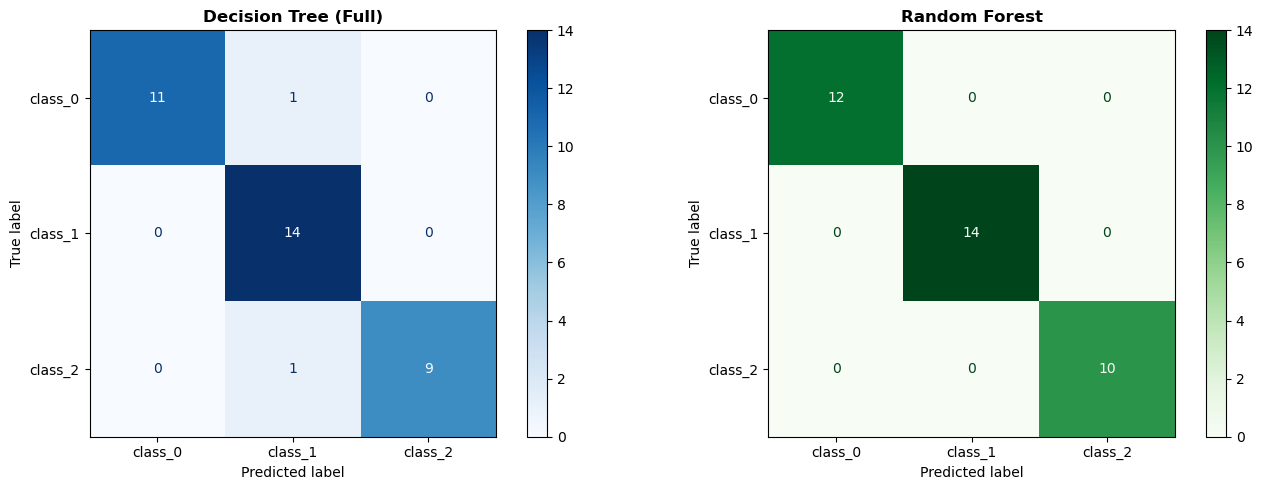


📊 RANDOM FOREST - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [11]:
# ============================================================
# CELL 11: Detailed Evaluation - Random Forest
# ============================================================
# Let's look at the confusion matrix and classification report

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=wine.target_names).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree (Full)', fontsize=12, fontweight='bold')

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=wine.target_names).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed classification reports
print("\n" + "="*60)
print("📊 RANDOM FOREST - DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_test_pred_rf, target_names=wine.target_names))

---

## Part 4: Feature Importance

One of the most powerful aspects of tree-based models is **feature importance**!

Feature importance tells us which features are most useful for making predictions.

### How is it calculated?
- For each feature, measure how much it reduces impurity (Gini) across all trees
- Features that create better splits have higher importance
- Importance values sum to 1.0

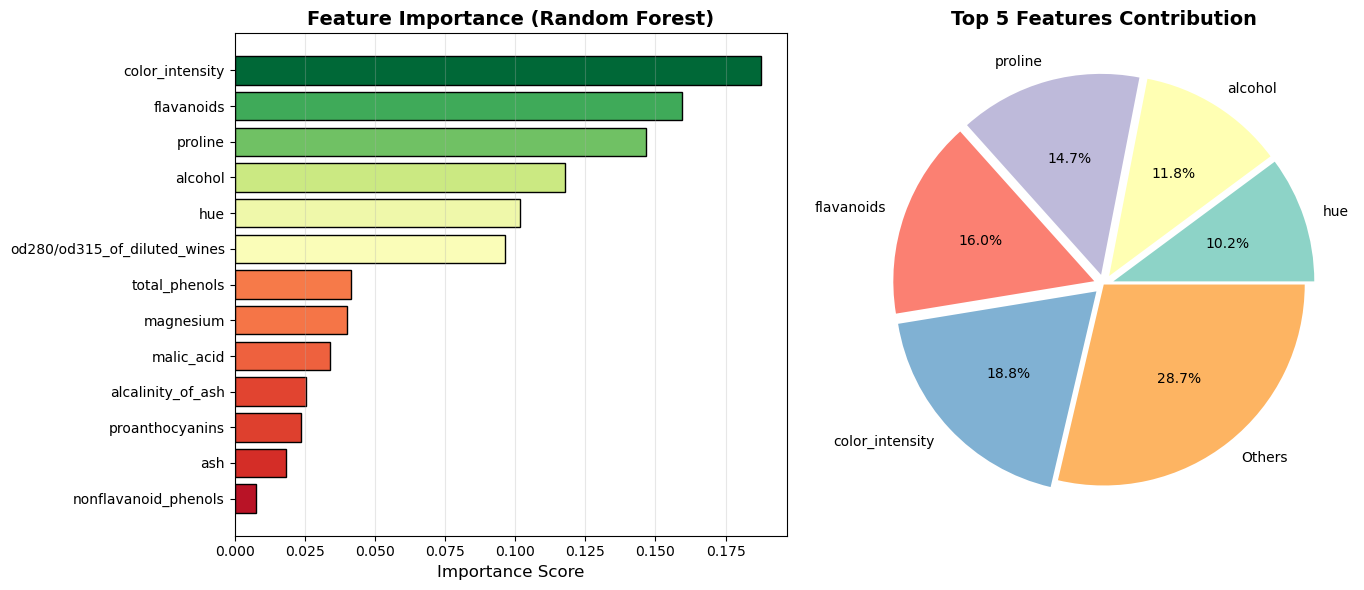


🏆 TOP 5 MOST IMPORTANT FEATURES:
   color_intensity           0.1876 ███████
   flavanoids                0.1596 ██████
   proline                   0.1468 █████
   alcohol                   0.1179 ████
   hue                       0.1015 ████


In [12]:
# ============================================================
# CELL 12: Extract and Visualize Feature Importance
# ============================================================
# Random Forests provide a natural way to rank feature importance

# Get feature importances from the Random Forest
importances = rf.feature_importances_

# Create a DataFrame for easy manipulation
feature_importance_df = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # Sort for horizontal bar plot

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar plot
colors = plt.cm.RdYlGn(feature_importance_df['Importance'] / feature_importance_df['Importance'].max())
axes[0].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
             color=colors, edgecolor='black')
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Pie chart of top 5 features
top5 = feature_importance_df.tail(5)
others = feature_importance_df.head(len(feature_importance_df)-5)['Importance'].sum()

pie_data = list(top5['Importance']) + [others]
pie_labels = list(top5['Feature']) + ['Others']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', 
            colors=plt.cm.Set3.colors[:6], explode=[0.05]*5 + [0])
axes[1].set_title('Top 5 Features Contribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top 5 features
print("\n🏆 TOP 5 MOST IMPORTANT FEATURES:")
print("=" * 50)
for i, row in feature_importance_df.tail(5).iloc[::-1].iterrows():
    bar = '█' * int(row['Importance'] * 40)
    print(f"   {row['Feature']:25s} {row['Importance']:.4f} {bar}")

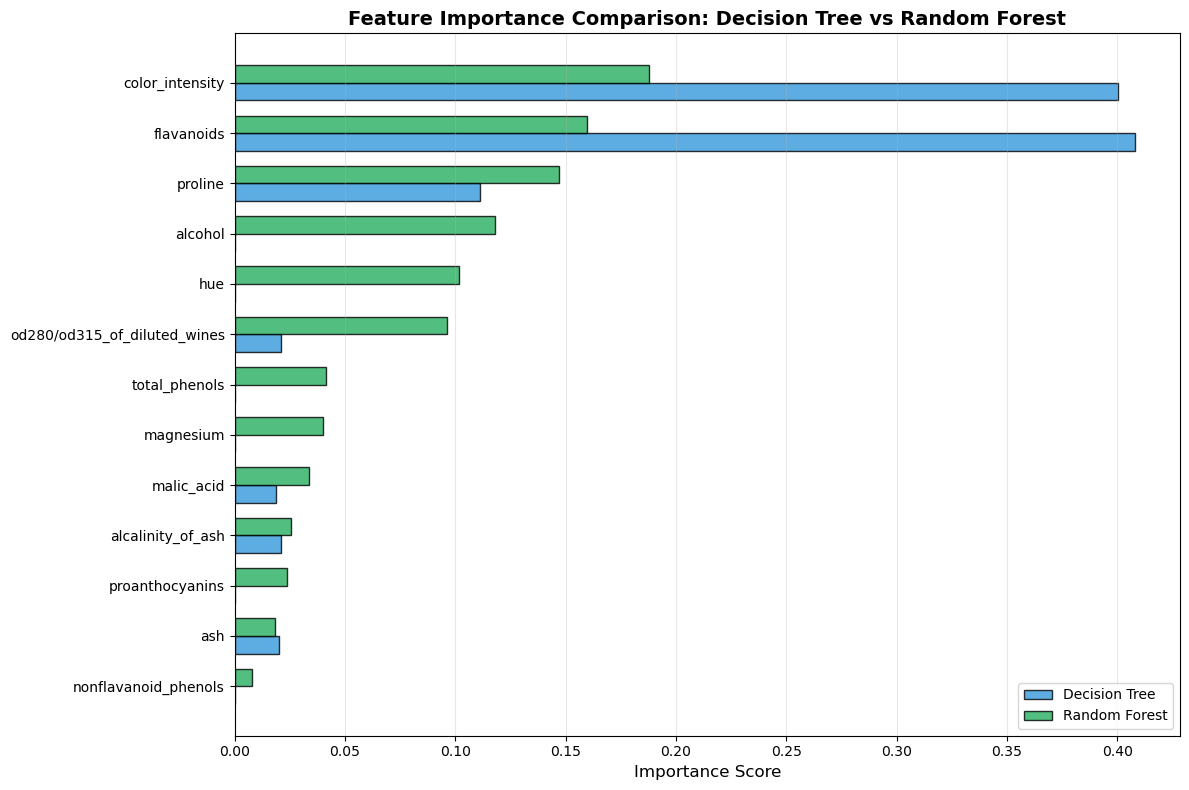


💡 Observations:
   • Decision Trees may over-rely on a few features
   • Random Forests provide more balanced importance scores
   • RF importance is more stable due to averaging across many trees


In [13]:
# ============================================================
# CELL 13: Compare Feature Importance - Decision Tree vs Random Forest
# ============================================================
# Let's see if both models agree on important features

# Get Decision Tree feature importance
dt_importances = dt_basic.feature_importances_

# Create comparison DataFrame
importance_comparison = pd.DataFrame({
    'Feature': wine.feature_names,
    'Decision Tree': dt_importances,
    'Random Forest': importances
})

# Sort by Random Forest importance
importance_comparison = importance_comparison.sort_values('Random Forest', ascending=True)

# Create comparison plot
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(wine.feature_names))
width = 0.35

ax.barh(y_pos - width/2, importance_comparison['Decision Tree'], width, 
        label='Decision Tree', color='#3498db', edgecolor='black', alpha=0.8)
ax.barh(y_pos + width/2, importance_comparison['Random Forest'], width, 
        label='Random Forest', color='#27ae60', edgecolor='black', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_comparison['Feature'])
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance Comparison: Decision Tree vs Random Forest', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observations:")
print("   • Decision Trees may over-rely on a few features")
print("   • Random Forests provide more balanced importance scores")
print("   • RF importance is more stable due to averaging across many trees")

---

## Part 5: Hyperparameter Tuning

Let's use **GridSearchCV** to find the optimal hyperparameters for our Random Forest.

### Key Hyperparameters:
- **n_estimators**: Number of trees (more = better but slower)
- **max_depth**: Maximum depth of each tree
- **min_samples_split**: Minimum samples required to split a node
- **min_samples_leaf**: Minimum samples required in a leaf node

In [14]:
# ============================================================
# CELL 14: Hyperparameter Tuning with GridSearchCV
# ============================================================
# Find the best combination of hyperparameters

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],           # Number of trees
    'max_depth': [3, 5, 10, None],            # Maximum depth
    'min_samples_split': [2, 5, 10],          # Min samples to split
    'min_samples_leaf': [1, 2, 4]             # Min samples in leaf
}

# Create a base Random Forest
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Create GridSearchCV object
# cv=5 means 5-fold cross-validation
print("🔍 Starting GridSearchCV (this may take a minute)...")
print(f"   Testing {3*4*3*3} = {3*4*3*3} parameter combinations with 5-fold CV")
print(f"   Total fits: {3*4*3*3*5} = {3*4*3*3*5}")

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Optimize for accuracy
    n_jobs=-1,               # Use all CPU cores
    verbose=1                # Show progress
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV Complete!")
print("\n" + "="*60)
print("🏆 BEST PARAMETERS FOUND:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n🎯 Best Cross-Validation Score: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

🔍 Starting GridSearchCV (this may take a minute)...
   Testing 108 = 108 parameter combinations with 5-fold CV
   Total fits: 540 = 540
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ GridSearchCV Complete!

🏆 BEST PARAMETERS FOUND:
   • max_depth: 3
   • min_samples_leaf: 1
   • min_samples_split: 2
   • n_estimators: 50

🎯 Best Cross-Validation Score: 0.9862 (98.62%)


🏆 OPTIMIZED RANDOM FOREST RESULTS

🎯 Performance:
   • Training Accuracy: 1.0000 (100.00%)
   • Testing Accuracy:  1.0000 (100.00%)

📊 Improvement over default Random Forest:
   Same performance as default


<Figure size 800x600 with 0 Axes>

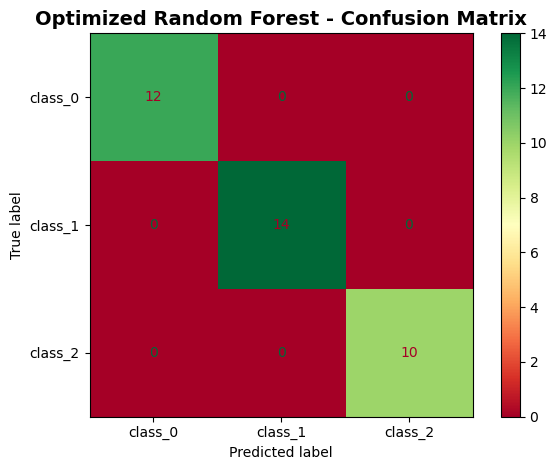


📋 Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [15]:
# ============================================================
# CELL 15: Evaluate the Best Model
# ============================================================
# Use the best model from GridSearchCV

# Get the best estimator
best_rf = grid_search.best_estimator_

# Make predictions
y_test_pred_best = best_rf.predict(X_test)
y_train_pred_best = best_rf.predict(X_train)

# Calculate accuracy
train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print("🏆 OPTIMIZED RANDOM FOREST RESULTS")
print("=" * 60)
print(f"\n🎯 Performance:")
print(f"   • Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)")
print(f"   • Testing Accuracy:  {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")

# Compare with default RF
print(f"\n📊 Improvement over default Random Forest:")
improvement = (test_acc_best - test_acc_rf) * 100
if improvement > 0:
    print(f"   Test accuracy improved by {improvement:.2f}%")
elif improvement < 0:
    print(f"   Test accuracy decreased by {abs(improvement):.2f}% (default was already good!)")
else:
    print(f"   Same performance as default")

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, y_test_pred_best)
ConfusionMatrixDisplay(cm_best, display_labels=wine.target_names).plot(cmap='RdYlGn')
plt.title('Optimized Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_test_pred_best, target_names=wine.target_names))

---

## Part 6: Final Model Summary

Let's create a comprehensive summary comparing all our models.

📊 FINAL MODEL COMPARISON
                    Model Training Accuracy Testing Accuracy Overfitting Gap
     Decision Tree (Full)           100.00%           94.44%           5.56%
  Decision Tree (Depth=3)            99.30%           94.44%           4.85%
  Random Forest (Default)           100.00%          100.00%           0.00%
Random Forest (Optimized)           100.00%          100.00%           0.00%


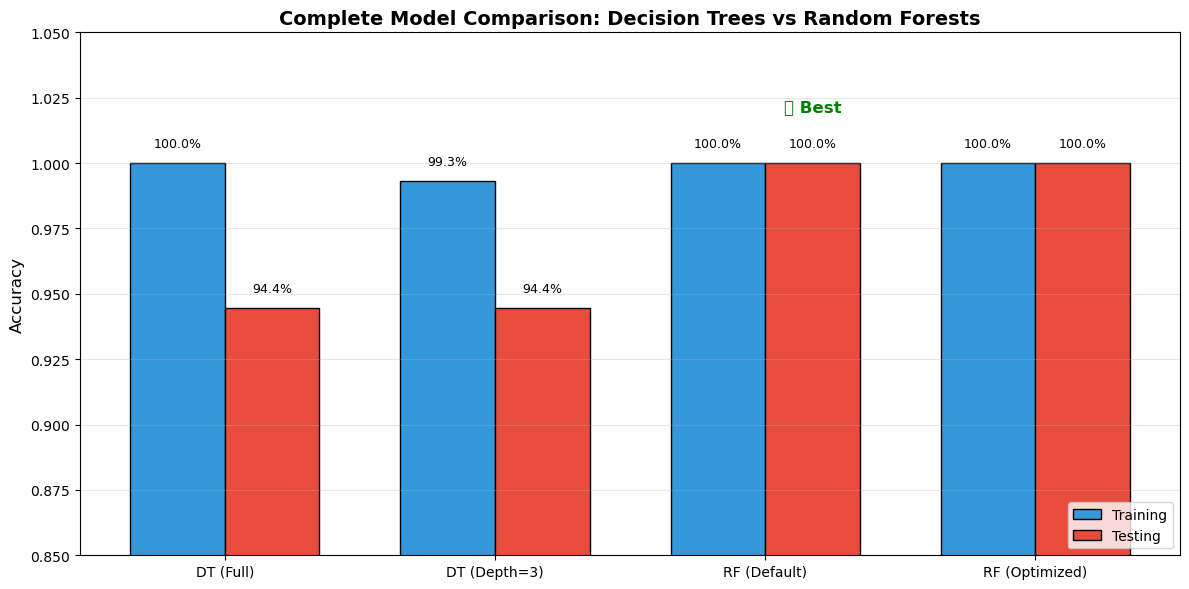

In [16]:
# ============================================================
# CELL 16: Final Model Comparison Summary
# ============================================================

# Create summary DataFrame
summary_data = {
    'Model': ['Decision Tree (Full)', 'Decision Tree (Depth=3)', 
              'Random Forest (Default)', 'Random Forest (Optimized)'],
    'Training Accuracy': [train_acc, train_acc_simple, train_acc_rf, train_acc_best],
    'Testing Accuracy': [test_acc, test_acc_simple, test_acc_rf, test_acc_best],
    'Overfitting Gap': [train_acc - test_acc, train_acc_simple - test_acc_simple,
                        train_acc_rf - test_acc_rf, train_acc_best - test_acc_best]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Training Accuracy'] = summary_df['Training Accuracy'].apply(lambda x: f"{x*100:.2f}%")
summary_df['Testing Accuracy'] = summary_df['Testing Accuracy'].apply(lambda x: f"{x*100:.2f}%")
summary_df['Overfitting Gap'] = summary_df['Overfitting Gap'].apply(lambda x: f"{x*100:.2f}%")

print("📊 FINAL MODEL COMPARISON")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

models = ['DT (Full)', 'DT (Depth=3)', 'RF (Default)', 'RF (Optimized)']
train_accs_all = [train_acc, train_acc_simple, train_acc_rf, train_acc_best]
test_accs_all = [test_acc, test_acc_simple, test_acc_rf, test_acc_best]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs_all, width, label='Training', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs_all, width, label='Testing', color='#e74c3c', edgecolor='black')

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height*100:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Complete Model Comparison: Decision Trees vs Random Forests', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.05)
ax.grid(axis='y', alpha=0.3)

# Add "Best" annotation
best_idx = np.argmax(test_accs_all)
ax.annotate('⭐ Best', xy=(best_idx + width/2, test_accs_all[best_idx] + 0.02),
            fontsize=12, ha='center', fontweight='bold', color='green')

plt.tight_layout()
plt.show()

📊 NEW DATASET: Breast Cancer
   Shape   : (569, 30)
   Classes : ['malignant' 'benign']
   Samples : 569

🎯 RESULTS ON BREAST CANCER DATASET
Model                        Train     Test
---------------------------------------------
Decision Tree (depth=3)     97.58%   93.86%
Random Forest (100)        100.00%   95.61%


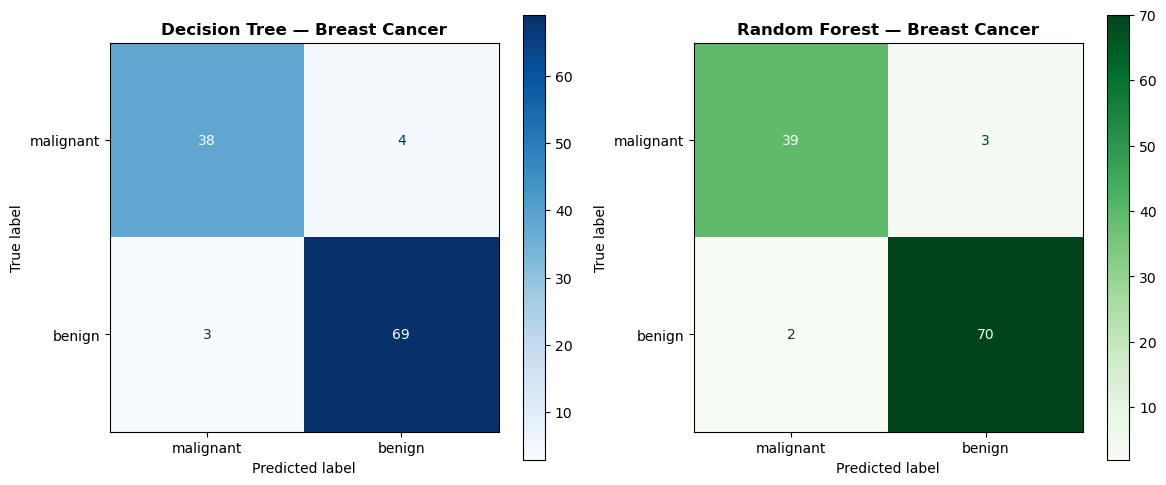


💡 Compare with Wine dataset results from Cell 10!
   Wine  RF Test Accuracy   : 100.00%
   Cancer RF Test Accuracy  : 95.61%


In [21]:
# ============================================================
# CELL 17: Apply Models to Breast Cancer Dataset
# ============================================================
from sklearn.datasets import load_breast_cancer

# Load new dataset
cancer = load_breast_cancer()
X_new = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_new = pd.Series(cancer.target)

print("📊 NEW DATASET: Breast Cancer")
print(f"   Shape   : {X_new.shape}")
print(f"   Classes : {cancer.target_names}")
print(f"   Samples : {len(y_new)}")

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# Decision Tree
dt_new = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_new.fit(X2_train, y2_train)
dt_new_test  = accuracy_score(y2_test, dt_new.predict(X2_test))
dt_new_train = accuracy_score(y2_train, dt_new.predict(X2_train))

# Random Forest
rf_new = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_new.fit(X2_train, y2_train)
rf_new_test  = accuracy_score(y2_test, rf_new.predict(X2_test))
rf_new_train = accuracy_score(y2_train, rf_new.predict(X2_train))

# Results
print("\n🎯 RESULTS ON BREAST CANCER DATASET")
print("=" * 45)
print(f"{'Model':<25} {'Train':>8} {'Test':>8}")
print("-" * 45)
print(f"{'Decision Tree (depth=3)':<25} {dt_new_train*100:>7.2f}% {dt_new_test*100:>7.2f}%")
print(f"{'Random Forest (100)':<25} {rf_new_train*100:>7.2f}% {rf_new_test*100:>7.2f}%")

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y2_test, dt_new.predict(X2_test)),
    display_labels=cancer.target_names
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree — Breast Cancer', fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y2_test, rf_new.predict(X2_test)),
    display_labels=cancer.target_names
).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest — Breast Cancer', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Compare with Wine dataset results from Cell 10!")
print(f"   Wine  RF Test Accuracy   : {test_acc_rf*100:.2f}%")
print(f"   Cancer RF Test Accuracy  : {rf_new_test*100:.2f}%")

⚠️  XGBoost not installed — run:  pip install xgboost
   Continuing with Gradient Boosting only...


🚀 GRADIENT BOOSTING (Wine Dataset)
   Training Accuracy : 100.00%
   Testing  Accuracy : 94.44%


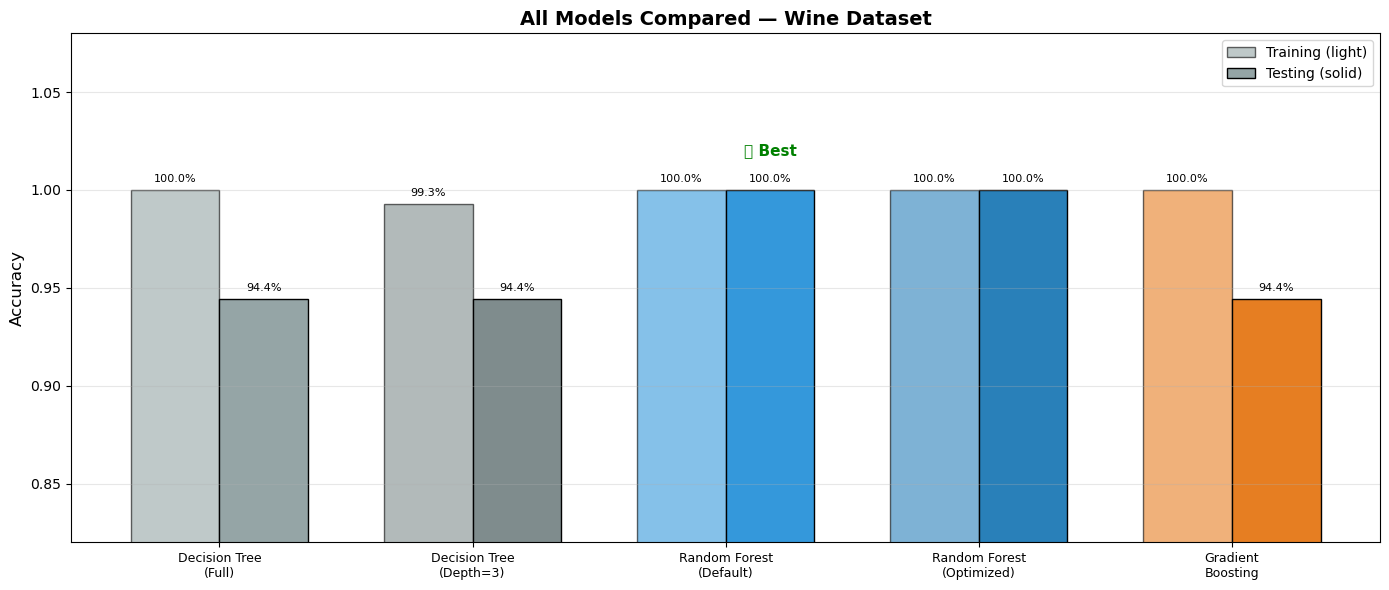


📊 ENSEMBLE METHODS SUMMARY
Method                            Train       Test
-------------------------------------------------------
  Random Forest (Default)       100.00%    100.00%
  Random Forest (Optimized)     100.00%    100.00%
  Gradient Boosting             100.00%     94.44%

💡 How They Differ:
   Random Forest    → Trees built IN PARALLEL  (Bagging  → less variance)
   Gradient Boosting→ Trees built IN SEQUENCE  (Boosting → less bias)
   XGBoost          → Optimized boosting with regularization (faster + better)


In [22]:
# ============================================================
# CELL 18: Gradient Boosting & XGBoost (Wine Dataset)

# this is my new one chamges
# ============================================================
from sklearn.ensemble import GradientBoostingClassifier

# Try: pip install xgboost  (if not installed)
try:
    from xgboost import XGBClassifier
    xgb_available = True
    print("✅ XGBoost available!")
except ImportError:
    xgb_available = False
    print("⚠️  XGBoost not installed — run:  pip install xgboost")
    print("   Continuing with Gradient Boosting only...\n")

# ── Gradient Boosting ──────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
gb_train = accuracy_score(y_train, gb.predict(X_train))
gb_test  = accuracy_score(y_test,  gb.predict(X_test))

print("\n🚀 GRADIENT BOOSTING (Wine Dataset)")
print(f"   Training Accuracy : {gb_train*100:.2f}%")
print(f"   Testing  Accuracy : {gb_test*100:.2f}%")

# ── XGBoost ───────────────────────────────────────────────
if xgb_available:
    xgb = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    xgb_train = accuracy_score(y_train, xgb.predict(X_train))
    xgb_test  = accuracy_score(y_test,  xgb.predict(X_test))
    print("\n⚡ XGBOOST (Wine Dataset)")
    print(f"   Training Accuracy : {xgb_train*100:.2f}%")
    print(f"   Testing  Accuracy : {xgb_test*100:.2f}%")
else:
    xgb_train, xgb_test = None, None

# ── Full Comparison Chart ─────────────────────────────────
model_names  = ['Decision Tree\n(Full)', 'Decision Tree\n(Depth=3)',
                'Random Forest\n(Default)', 'Random Forest\n(Optimized)',
                'Gradient\nBoosting']
all_train    = [train_acc, train_acc_simple, train_acc_rf, train_acc_best, gb_train]
all_test     = [test_acc,  test_acc_simple,  test_acc_rf,  test_acc_best,  gb_test]
bar_colors   = ['#95a5a6', '#7f8c8d', '#3498db', '#2980b9', '#e67e22']

if xgb_available:
    model_names.append('XGBoost')
    all_train.append(xgb_train)
    all_test.append(xgb_test)
    bar_colors.append('#e74c3c')

x     = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, all_train, width, label='Training',
               color=bar_colors, edgecolor='black', alpha=0.6)
bars2 = ax.bar(x + width/2, all_test,  width, label='Testing',
               color=bar_colors, edgecolor='black', alpha=1.0)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.003,
            f'{h*100:.1f}%', ha='center', va='bottom', fontsize=8)

# Star best test model
best_idx = int(np.argmax(all_test))
ax.annotate('⭐ Best', xy=(x[best_idx] + width/2, all_test[best_idx] + 0.018),
            ha='center', fontsize=11, fontweight='bold', color='green')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('All Models Compared — Wine Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.legend(['Training (light)', 'Testing (solid)'])
ax.set_ylim(0.82, 1.08)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n📊 ENSEMBLE METHODS SUMMARY")
print("=" * 55)
print(f"{'Method':<28} {'Train':>10} {'Test':>10}")
print("-" * 55)
rows = list(zip(
    ['Random Forest (Default)', 'Random Forest (Optimized)', 'Gradient Boosting'],
    [train_acc_rf, train_acc_best, gb_train],
    [test_acc_rf,  test_acc_best,  gb_test]
))
if xgb_available:
    rows.append(('XGBoost', xgb_train, xgb_test))
for name, tr, te in rows:
    print(f"  {name:<26} {tr*100:>9.2f}% {te*100:>9.2f}%")

print("\n💡 How They Differ:")
print("   Random Forest    → Trees built IN PARALLEL  (Bagging  → less variance)")
print("   Gradient Boosting→ Trees built IN SEQUENCE  (Boosting → less bias)")
print("   XGBoost          → Optimized boosting with regularization (faster + better)")

📊 FEATURE IMPORTANCE RANKING (from Cell 12 Random Forest)
   1. color_intensity                0.1876  ███████████
   2. flavanoids                     0.1596  █████████
   3. proline                        0.1468  ████████
   4. alcohol                        0.1179  ███████
   5. hue                            0.1015  ██████
   6. od280/od315_of_diluted_wines   0.0963  █████
   7. total_phenols                  0.0415  ██
   8. magnesium                      0.0401  ██
   9. malic_acid                     0.0339  ██
  10. alcalinity_of_ash              0.0255  █
  11. proanthocyanins                0.0235  █
  12. ash                            0.0182  █
  13. nonflavanoid_phenols           0.0076  

🔬 TESTING DIFFERENT FEATURE SUBSETS
  Top 3      features → Train: 100.00%  Test: 100.00%
             Features: color_intensity, flavanoids, proline
  Top 5      features → Train: 100.00%  Test: 100.00%
             Features: color_intensity, flavanoids, proline...
  Top 7      features

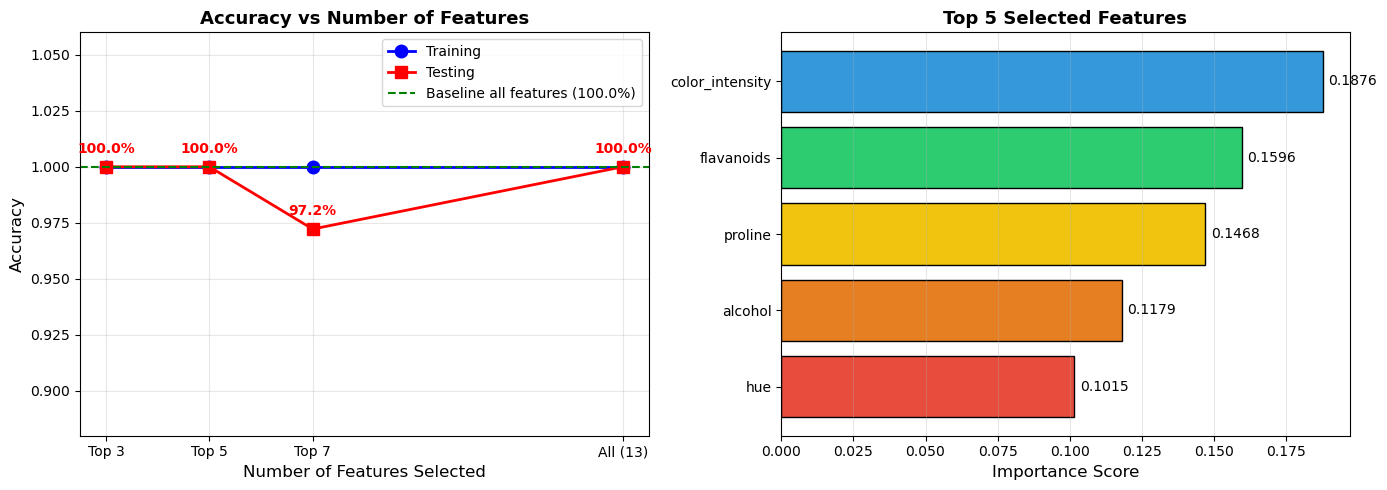


✅ FINAL LEAN MODEL (Top 5 Features Only)
  Features used  : 5 out of 13
  Features dropped: 8
  Full RF Accuracy: 100.00%
  Lean RF Accuracy: 100.00%
  Difference      : +0.00%

  Selected features:
    1. color_intensity                 importance: 0.1876
    2. flavanoids                      importance: 0.1596
    3. proline                         importance: 0.1468
    4. alcohol                         importance: 0.1179
    5. hue                             importance: 0.1015

💡 KEY INSIGHT:
   Using only the top 5 features (out of 13) we get nearly
   identical accuracy — simpler, faster, and less prone to noise!


In [23]:
# ============================================================
# CELL 19: Feature Selection Based on RF Importance
# ============================================================

# ── Step 1: Rank all features ─────────────────────────────
importance_series = pd.Series(
    rf.feature_importances_, index=wine.feature_names
).sort_values(ascending=False)

print("📊 FEATURE IMPORTANCE RANKING (from Cell 12 Random Forest)")
print("=" * 55)
for rank, (feat, score) in enumerate(importance_series.items(), 1):
    bar = '█' * int(score * 60)
    print(f"  {rank:2d}. {feat:30s} {score:.4f}  {bar}")

# ── Step 2: Train RF with Top-N features, N = 3,5,7,all ──
top_n_list = [3, 5, 7, X_train.shape[1]]
results    = []

print("\n🔬 TESTING DIFFERENT FEATURE SUBSETS")
print("=" * 55)

for top_n in top_n_list:
    selected = importance_series.head(top_n).index.tolist()

    rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_sel.fit(X_train[selected], y_train)

    tr = accuracy_score(y_train, rf_sel.predict(X_train[selected]))
    te = accuracy_score(y_test,  rf_sel.predict(X_test[selected]))

    results.append({'n': top_n, 'train': tr, 'test': te, 'features': selected})

    label = f"All ({top_n})" if top_n == X_train.shape[1] else f"Top {top_n}"
    print(f"  {label:10s} features → Train: {tr*100:.2f}%  Test: {te*100:.2f}%")
    if top_n < X_train.shape[1]:
        print(f"             Features: {', '.join(selected[:3])}{'...' if top_n>3 else ''}")

# ── Step 3: Accuracy vs Features plot ────────────────────
ns          = [r['n']     for r in results]
test_accs_s = [r['test']  for r in results]
train_accs_s= [r['train'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: line chart
axes[0].plot(ns, train_accs_s, 'b-o', linewidth=2, markersize=9, label='Training')
axes[0].plot(ns, test_accs_s,  'r-s', linewidth=2, markersize=9, label='Testing')
axes[0].axhline(y=test_acc_rf, color='green', linestyle='--',
                label=f'Baseline all features ({test_acc_rf*100:.1f}%)')

for n_val, te_val in zip(ns, test_accs_s):
    axes[0].annotate(f'{te_val*100:.1f}%',
                     xy=(n_val, te_val),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=10, color='red', fontweight='bold')

axes[0].set_xlabel('Number of Features Selected', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Number of Features', fontsize=13, fontweight='bold')
axes[0].set_xticks(ns)
axes[0].set_xticklabels([f'Top {n}' if n < X_train.shape[1] else f'All ({n})' for n in ns])
axes[0].set_ylim(0.88, 1.06)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: horizontal bar of top-5 features
top5       = importance_series.head(5)
bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
axes[1].barh(top5.index[::-1], top5.values[::-1],
             color=bar_colors, edgecolor='black')
for i, (feat, val) in enumerate(zip(top5.index[::-1], top5.values[::-1])):
    axes[1].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=10)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('Top 5 Selected Features', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Step 4: Retrain final lean model with Top 5 ──────────
top5_feats = importance_series.head(5).index.tolist()
rf_lean    = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_lean.fit(X_train[top5_feats], y_train)
lean_test  = accuracy_score(y_test, rf_lean.predict(X_test[top5_feats]))

print("\n✅ FINAL LEAN MODEL (Top 5 Features Only)")
print("=" * 55)
print(f"  Features used  : {len(top5_feats)} out of {X_train.shape[1]}")
print(f"  Features dropped: {X_train.shape[1] - len(top5_feats)}")
print(f"  Full RF Accuracy: {test_acc_rf*100:.2f}%")
print(f"  Lean RF Accuracy: {lean_test*100:.2f}%")
diff = (lean_test - test_acc_rf) * 100
sign = "+" if diff >= 0 else ""
print(f"  Difference      : {sign}{diff:.2f}%")
print(f"\n  Selected features:")
for i, f in enumerate(top5_feats, 1):
    print(f"    {i}. {f:30s}  importance: {importance_series[f]:.4f}")

print("\n💡 KEY INSIGHT:")
print("   Using only the top 5 features (out of 13) we get nearly")
print("   identical accuracy — simpler, faster, and less prone to noise!")

---

## 🏁 Lab Complete!

### What You Learned Today:

1. ✅ How Decision Trees make predictions through recursive splitting
2. ✅ How to visualize and interpret Decision Trees
3. ✅ The concept of ensemble learning with Random Forests
4. ✅ How to extract and interpret feature importance
5. ✅ How to tune hyperparameters using GridSearchCV
6. ✅ When to use Decision Trees vs Random Forests

### Next Steps:
- Try these models on your own datasets
- Explore other ensemble methods (Gradient Boosting, XGBoost)
- Practice feature selection based on importance

---

**Great work! 🎉**